In [2]:
from PIL import Image, ImageOps
import numpy as np, os
src = "사진경로" #사진경로

if os.path.exists(src):
    img = ImageOps.exif_transpose(Image.open(src)).convert("RGB")
    ImageOps.fit(img, (320, 240)).save("sample.jpg")
else: #사진이 없으면 샘플 이미지 생성
    yy, xx = np.mgrid[0:240, 0:320]
    img = np.stack([(xx / 320 * 255).astype(np.uint8), 
                    (yy / 240 * 255).astype(np.uint8), 
                    np.full((240, 320), 128, dtype=np.uint8)], axis=-1)
    img[(xx - 160) ** 2 + (yy - 120) ** 2 < 60 ** 2] = 255
    Image.fromarray(img).save("sample.jpg")
print(np.array(Image.open("sample.jpg")).shape) #(240, 320, 3)

(240, 320, 3)


In [ ]:
#예제 3-1. 사진 > 숫자표 >픽셀 찍어 보기
from PIL import Image
import numpy as np
img = Image.open("sample.jpg")
a = np.array(img) # 사진 > 숫자 배열
print(a.shape, a.dtype) #(240, 320, 3) uint8
print(a[0, 0]) # [ 0 0 119]
print(a[120, 160]) # [255 255 255] (중앙 픽셀)
print(a.min(), a.max()) # 0 255
print(a[:,:, 0].mean().round(1)) # 145.3(R 평균, 다른 값)


(240, 320, 3) uint8
[  0   0 127]
[255 255 255]
0 255
145.2


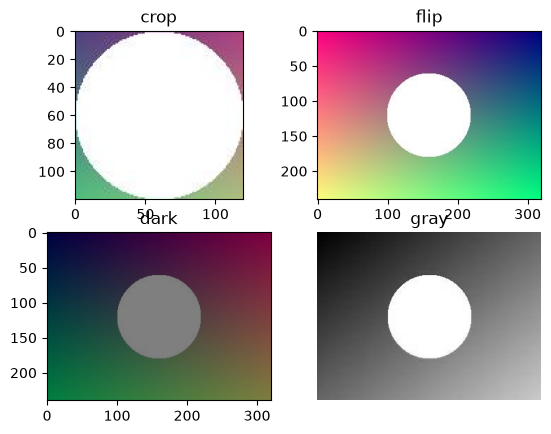

(120, 120, 3) (240, 320, 3) (240, 320)


In [2]:
# 예제 3-2. 자르기, 뒤집기, 어둡게, 흑백 명령 4개 그대로

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
a = np.array(Image.open("sample.jpg"))# (240, 320, 3)
crop = a[60:180, 100:220] #자르기: 행 60 ~ 179, 열 100 ~ 219
flip = a[:,::-1] #ㅈ 좌우 반전: 열 순서 뒤집기
dark = (a*0.5).astype(np.uint8)#어둡게 : 모든픽셀 x 0.5
gray = a.mean(axis=2).astype(np.uint8)
pairs = [("crop", crop),("flip",flip),("dark",dark),("gray",gray)]
for i, (name, im) in enumerate(pairs):
    plt.subplot(2,2,i+1); plt.imshow(im, cmap = "gray"); plt.title(name);
plt.axis("off")
plt.show()
print(crop.shape, flip.shape, gray.shape)

torch.Size([28, 28]) 255 5
...........############.....
.........#.###...#..........
............##..............
...............####.........
...............#####........
..........######............


C:\Users\user\AppData\Local\Temp\ipykernel_46584\1367693617.py:7: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  t = torch.tensor(list(img.getdata())).view(28, 28) #픽셀 > (28, 28)


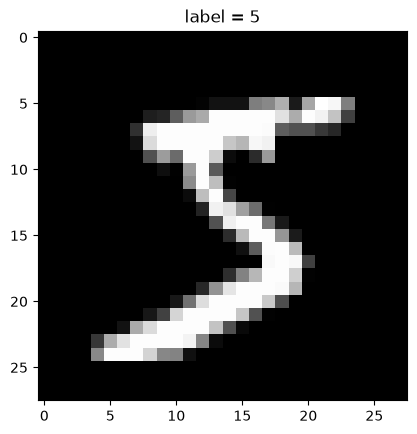

In [9]:
#예제 3-3 손글씨 한장 > 숫자표> 글자로 찍기
import matplotlib.pyplot as plt
import torch
from torchvision import datasets
mnist = datasets.MNIST(root="data", train=True, download=True) # 첫 실행 시 다운로드
img, label = mnist[0] #0 번째 샘플:(PIL이미지, 정답)
t = torch.tensor(list(img.getdata())).view(28, 28) #픽셀 > (28, 28)
print(t.shape, t.max().item(), label) # > torch.Size([28, 28]) 255 5
for row in t[6:22:3]: #ASCII 아트(3줄마다)
    print("".join("#" if v > 128 else "." for v in row))
plt.imshow(t.numpy(), cmap="gray"); plt.title(f"label = {label}"); plt.show()

(240, 320, 3) (120, 160, 3)
255 (240, 320)


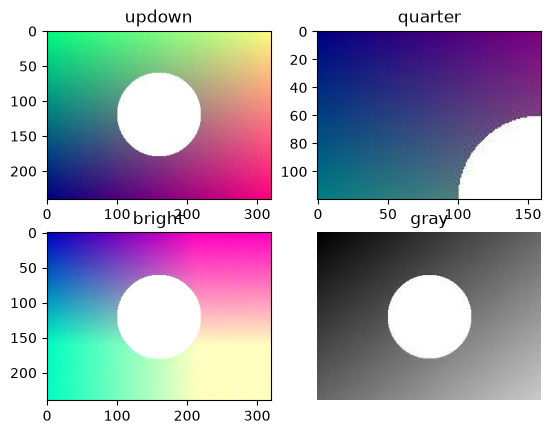

(120, 160, 3) (240, 320, 3) (240, 320)


In [23]:
#실습1 정답예시
from PIL import Image
import numpy as np
a = np.array(Image.open("sample.jpg"))
updown = a[::-1] # 상하반전
quarter = a[:120, :160] # 왼쪽 위1/4
bright = np.clip(a * 1.5, 0, 255).astype(np.uint8)
#1.5배 밝게

gray = a.mean(axis = 2).astype(np.uint8)
#흑백


print(updown.shape, quarter.shape)
#(240, 320, 3) (120, 160, 3)

print(bright.max(), gray.shape)
# 255(240, 320)``

pairs = [("updown", updown),("quarter",quarter),("bright",bright),("gray",gray)]
for i, (name, im) in enumerate(pairs):
    plt.subplot(2,2,i+1); plt.imshow(im, cmap = "gray"); plt.title(name);
plt.axis("off")
plt.show()
print(crop.shape, flip.shape, gray.shape)